# Transient heat equation on a U-shaped domain — AlphaPINN spectral PINN

**PDE:**  $\partial_t u - \kappa\,\Delta u = 0$  (heat / diffusion)

**Domain:**  $[0,2]\times[0,2]$ minus a notch $(x\in(0.6,1.4),\; y>0.8)$,  time $t\in[0,T]$

**Initial condition:**  $u(x,y,0) = 0$

**Boundary conditions:**
- $u = 1$ on the **left-arm top** ($y=2,\; x\in[0,0.6]$) — hot, held for all $t$
- $u = 0$ everywhere else on the boundary — cold, held for all $t$

**Method:**  **AlphaPINN — global spectral PINN without Method of Lines.**

Since the Laplace eigenvectors $\Phi$ are global spatial modes, the full
space-time solution can be written as:

$$u(x,t) = \Phi\,\alpha(t), \quad \alpha(t) = \text{FNN}(t) \in \mathbb{R}^K$$

The FNN takes only $t$ as input and outputs the spectral expansion coefficients.
Time derivatives follow by autodiff; no state, no rollout, no BPTT.

Physics is enforced through the Galerkin weak-form residual:

$$\int_\Omega \phi\,\partial_t u\,d\Omega + \kappa\int_\Omega \nabla u\cdot\nabla\phi\,d\Omega = 0 \quad \forall\,\phi\in V_h, \; t\in[0,T]$$

The IC $u(\cdot,0)=0$ is added as a Dirichlet BC on the $t=0$ face of the domain.


## 1. Imports & environment

In [1]:
import os, sys
sys.path.insert(0, os.path.join(os.getcwd(), ".."))
os.environ.setdefault("PINNS_BACKEND", "jax")

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
from collections import Counter

import pygmsh

import jax
import jax.numpy as jnp

from pinns import DomainMeshContinuous, AlphaPINN, LaplacianFeatures
from pinns.backends.jax import Trainer
from pinns.problem_weak import ProblemWeak

## 2. Build the U-shaped triangulated mesh

Mesh: 311 nodes, 532 triangles


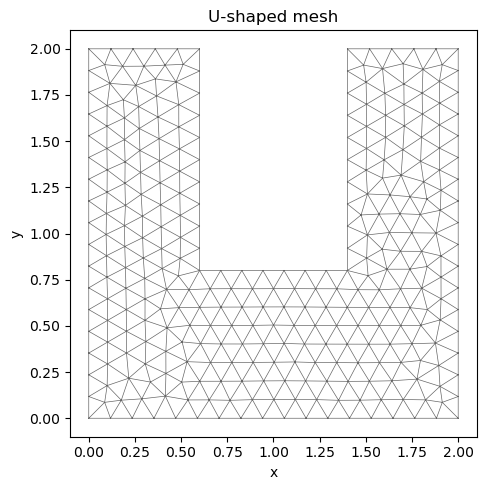

In [2]:
X_MAX    = 2.0
Y_MAX    = 2.0
NOTCH_X  = (0.6, 1.4)
NOTCH_Y  = 0.8
MESH_SIZE = 0.12

T_MAX    = 1.0    # total simulation time
KAPPA    = 0.05   # diffusion coefficient

def in_u_shape(pts: np.ndarray) -> np.ndarray:
    x, y   = pts[:, 0], pts[:, 1]
    in_box = (x >= 0) & (x <= X_MAX) & (y >= 0) & (y <= Y_MAX)
    in_cut = (x > NOTCH_X[0]) & (x < NOTCH_X[1]) & (y > NOTCH_Y)
    return in_box & ~in_cut

from pinns.meshes import u_shape as make_u_shape

verts, faces = make_u_shape(
    x_max=X_MAX, y_max=Y_MAX,
    notch_x=NOTCH_X, notch_y=NOTCH_Y,
    mesh_size=MESH_SIZE,
)
print(f"Mesh: {len(verts)} nodes, {len(faces)} triangles")

fig, ax = plt.subplots(figsize=(5, 5))
tri_vis = mtri.Triangulation(verts[:, 0], verts[:, 1], faces)
ax.triplot(tri_vis, "k-", lw=0.5, alpha=0.6)
ax.set_aspect("equal"); ax.set_title("U-shaped mesh")
ax.set_xlabel("x"); ax.set_ylabel("y")
plt.tight_layout(); plt.show()


## 3. Identify boundary nodes

Hot nodes  (u=1): 6
Cold nodes (u=0): 82
Interior nodes  : 223


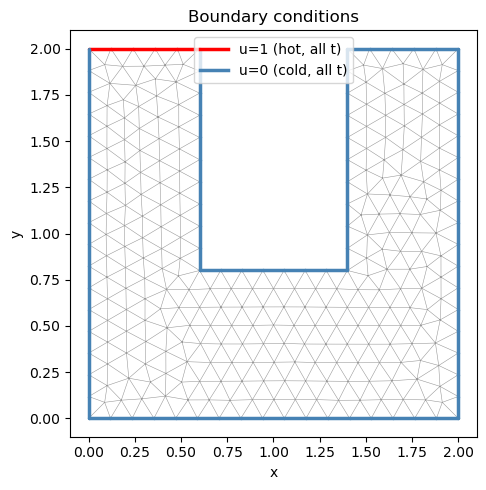

In [3]:
edge_count = Counter()
for tri_idx in faces:
    for i in range(3):
        e = tuple(sorted([tri_idx[i], tri_idx[(i + 1) % 3]]))
        edge_count[e] += 1

boundary_verts_idx = set()
for (v0, v1), cnt in edge_count.items():
    if cnt == 1:
        boundary_verts_idx.update([v0, v1])
boundary_verts_idx = np.array(sorted(boundary_verts_idx))

is_boundary = np.zeros(len(verts), dtype=bool)
is_boundary[boundary_verts_idx] = True

tol    = MESH_SIZE / 2
is_hot = (verts[:, 1] >= Y_MAX - tol) & (verts[:, 0] <= NOTCH_X[0] + tol) & is_boundary

print(f"Hot nodes  (u=1): {is_hot.sum()}")
print(f"Cold nodes (u=0): {(is_boundary & ~is_hot).sum()}")
print(f"Interior nodes  : {(~is_boundary).sum()}")

from matplotlib.lines import Line2D
fig, ax = plt.subplots(figsize=(5, 5))
ax.triplot(tri_vis, "k-", lw=0.4, alpha=0.4)
for (v0, v1), cnt in edge_count.items():
    if cnt == 1:
        color = "red" if (is_hot[v0] and is_hot[v1]) else "steelblue"
        ax.plot([verts[v0, 0], verts[v1, 0]], [verts[v0, 1], verts[v1, 1]],
                color=color, lw=2.5, solid_capstyle="round")
ax.legend(handles=[
    Line2D([0],[0], color="red",       lw=2.5, label="u=1 (hot, all t)"),
    Line2D([0],[0], color="steelblue", lw=2.5, label="u=0 (cold, all t)"),
])
ax.set_aspect("equal"); ax.set_title("Boundary conditions")
ax.set_xlabel("x"); ax.set_ylabel("y")
plt.tight_layout(); plt.show()

## 4. Finite-difference transient reference solution

Solve $\partial_t u = \kappa\,\Delta u$ with implicit Euler on a $100\times100$ regular grid.
The resulting space-time interpolant `fd_solution(x)` accepts columns $(x, y, t)$ and is
used by the trainer to log the relative L2 error at every checkpoint.

In [4]:
import scipy.sparse as sp
import scipy.sparse.linalg as spla
from scipy.interpolate import RegularGridInterpolator
from scipy.ndimage import distance_transform_edt

N_FD  = 100
xs_fd = np.linspace(0, X_MAX, N_FD + 1)
ys_fd = np.linspace(0, Y_MAX, N_FD + 1)
h_fd  = xs_fd[1] - xs_fd[0]
XX_fd, YY_fd = np.meshgrid(xs_fd, ys_fd, indexing='ij')

pts_flat = np.column_stack([XX_fd.ravel(), YY_fd.ravel()])
active   = in_u_shape(pts_flat).reshape(N_FD + 1, N_FD + 1)

node_id = np.full((N_FD + 1, N_FD + 1), -1, dtype=np.int64)
node_id[active] = np.arange(active.sum())
n_dof   = active.sum()
ii, jj  = np.where(active)

def _is_bnd(i, j):
    if not active[i, j]: return False
    for di, dj in [(-1,0),(1,0),(0,-1),(0,1)]:
        ni, nj = i+di, j+dj
        if ni < 0 or ni > N_FD or nj < 0 or nj > N_FD or not active[ni, nj]:
            return True
    return False

bnd    = np.array([_is_bnd(i, j) for i, j in zip(ii, jj)])
hot    = bnd & (YY_fd[ii, jj] >= Y_MAX - h_fd/2) & (XX_fd[ii, jj] <= NOTCH_X[0] + h_fd/2)
bc_val = np.where(hot, 1.0, 0.0)

# Stiffness matrix (κ × 5-point Laplacian)
rows, cols, vals = [], [], []
for idx, (i, j) in enumerate(zip(ii, jj)):
    k = node_id[i, j]
    if bnd[idx]:
        rows.append(k); cols.append(k); vals.append(-1.0)
    else:
        rows.append(k); cols.append(k); vals.append(-KAPPA * 4.0 / h_fd**2)
        for di, dj in [(-1,0),(1,0),(0,-1),(0,1)]:
            nk = node_id[i+di, j+dj]
            rows.append(k); cols.append(nk); vals.append(KAPPA / h_fd**2)

A_mat = sp.csr_matrix((vals, (rows, cols)), shape=(n_dof, n_dof))

N_TIME = 50
dt_fd  = T_MAX / N_TIME
ts_fd  = np.linspace(0, T_MAX, N_TIME + 1)

M_diag = np.ones(n_dof); M_diag[bnd] = 0.0
M_mat  = sp.diags(M_diag / dt_fd, format='csr')
LHS    = M_mat - A_mat
b_bc   = np.zeros(n_dof); b_bc[bnd] = bc_val[bnd]

u_cur = np.zeros(n_dof)
u_cur[bnd] = bc_val[bnd]
LHS_lu = spla.splu(LHS.tocsc())

U_grid = np.full((N_TIME + 1, N_FD + 1, N_FD + 1), np.nan)
U_grid[0][active] = u_cur

for n_step in range(N_TIME):
    rhs = (M_mat @ u_cur) + b_bc
    rhs[bnd] = bc_val[bnd]
    u_cur = LHS_lu.solve(rhs)
    U_grid[n_step + 1][active] = u_cur

print(f"FD transient (κ={KAPPA}): {n_dof} DOFs × {N_TIME} steps")
print(f"u range at t=T: [{np.nanmin(U_grid[-1]):.4f}, {np.nanmax(U_grid[-1]):.4f}]")

# ── Fill inactive cells (notch / outside bbox) with nearest-neighbour ────
# RegularGridInterpolator bilinearly interpolates over 2×2 grid cells.
# If any corner is NaN the whole cell returns NaN — this hits PINN nodes
# near the notch boundary whose enclosing grid cell has a corner outside
# the domain.  NN-fill makes every corner finite; fd_solution still masks
# truly out-of-domain queries with in_u_shape at query time.
U_grid_filled = U_grid.copy()
nan_mask_2d = ~active   # same inactive pattern at every time step
_, nn_idx = distance_transform_edt(nan_mask_2d, return_indices=True)
for t_idx in range(N_TIME + 1):
    frame = U_grid_filled[t_idx]
    frame[nan_mask_2d] = frame[nn_idx[0][nan_mask_2d], nn_idx[1][nan_mask_2d]]

# ── Regular-grid space-time interpolator ─────────────────────────────────
_fd_rgi = RegularGridInterpolator(
    (ts_fd, xs_fd, ys_fd), U_grid_filled,
    method='linear', bounds_error=False, fill_value=np.nan,
)

def fd_solution(x: np.ndarray) -> np.ndarray:
    """Space-time FD reference: (n_pts, 3) cols (x,y,t) → (n_pts,1)."""
    txy    = x[:, [2, 0, 1]]          # RegularGridInterpolator wants (t, x, y)
    vals   = _fd_rgi(txy).reshape(-1, 1)
    in_dom = in_u_shape(x[:, :2]).reshape(-1, 1)
    vals[~in_dom] = np.nan
    return vals

print("Regular-grid space-time interpolant ready.")


FD transient (κ=0.05): 7861 DOFs × 50 steps
u range at t=T: [-0.0000, 1.0000]
Regular-grid space-time interpolant ready.


## 5. Spatial domain & AlphaPINN spectral network

`DomainMeshContinuous` is used here: it signals that the network predicts
$u(x, t)$ **globally** over $[0, T]$ (not step-by-step).  `ProblemWeak`
assembles a continuous space-time weak form, sampling `n_time_points` random
time levels from $[0, T]$ each epoch.

The two typed subclasses of `DomainMesh` provide a clean API split:

| Class | Time model | `ProblemWeak` route |
|---|---|---|
| `DomainMeshContinuous` | continuous interval, random/quasi-random sampling | `make_loss_fn` — continuous space-time cubature |
| `DomainMeshDiscrete` | fixed `dt`, `n_steps` | `make_rollout_loss_fn` — implicit-Euler BPTT |

`t_sampling_method` options for `DomainMeshContinuous` (same API as `DomainCubic`):
`"uniform"` (default), `"midpoint"` (fixed grid), `"latin_hypercube"`, `"sobol"`, `"halton"`, or a callable.

`AlphaPINN` auto-detects the operational mode from the domain:
- **Continuous-time** (domain has `t_interval`, `use_state=False`): FNN takes $[\Phi(x),\, t]$ as input and outputs $u(x,t)$ directly — no state, no rollout, $\partial_t u$ by autodiff.
- **State-integrator** (`use_state=True`): $\Phi^\top u^n \to \Phi u^{n+1}$ — Method-of-Lines / BPTT.
- **Static** (no time, no state): steady-state solution.

`hidden_dims` gives full per-layer width control (like `FNN`): e.g. `[128, 128, 128, 128]`.


DomainMeshContinuous(2D × t∈[0.0, 1.0], sampling='uniform', n_time_points=20, n_nodes=311, n_conditions=3)


<Axes: title={'center': 't ∈ [0, 1]'}, xlabel='x', ylabel='y'>

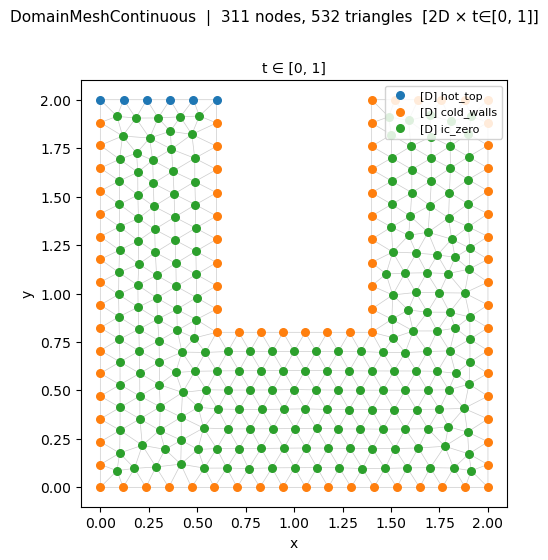

In [5]:
T_MAX    = 1.0    # total simulation time
KAPPA    = 0.05   # diffusion coefficient

# ── Space-time domain ────────────────────────────────────────────────────
domain = DomainMeshContinuous(
    (verts, faces),
    t_interval=[0.0, T_MAX],
    t_sampling_method="uniform",  # random per epoch (default)
    n_time_points=20,
)

# Spatial boundary conditions (held for all t).
# time_window defaults to [t_min, t_max] — active at every time.
domain.add_dirichlet(
    select=lambda v: is_hot,
    value=1.0,
    component=0,
    name="hot_top",
)
domain.add_dirichlet(
    select=lambda v: is_boundary & ~is_hot,
    value=0.0,
    component=0,
    name="cold_walls",
)

# Initial condition u(x,y,0)=0 — pins interior nodes only at t=t_min.
# time_window=[t_min, t_min] is set automatically.
domain.add_initial_condition(value=0.0, name="ic_zero")
print(domain)

domain.plot()

## 6. PDE problem & AlphaPINN network

$$\int_\Omega \phi\,\partial_t u\,d\Omega + \kappa\int_\Omega \nabla u\cdot\nabla\phi\,d\Omega = 0$$

**Design:**  `ProblemWeak` is defined **before** the network because it owns
the hard-constraint `output_transform` (built from the domain's Dirichlet BCs).
The network receives it as a constructor argument:

```python
problem = ProblemWeak(..., hard_constraints=True)
net     = AlphaPINN(..., output_transform=problem.output_transform)
```

`AlphaPINN` is literally `LaplacianFeatures(domain, n_features) + FNN(hidden_dims)`:

| Component | Role |
|---|---|
| `LaplacianFeatures` | Maps `(x,y,t)` → `[Φ(x,y), t]` via barycentric interp of mesh eigenvectors |
| `FNN(hidden_dims)` | Standard MLP: `n_features` → `hidden_dims` → `n_outputs` |

No `n_time_steps`, no BPTT.  $\partial_t u$ comes from autodiff through the FNN w.r.t. the appended $t$ feature.


In [ ]:
def volume_fn(x, y, params, phi, grad_phi, derivative=None):
    """Continuous transient weak form: ∫ φ ∂_t u dΩ + κ ∫ ∇u·∇φ dΩ"""
    kappa = params["fixed"]["kappa"]

    du_dt = derivative(y, x, 0, (2,))              # ∂u/∂t  (autodiff through FNN)
    du_dx = derivative(y, x, 0, (0,))              # ∂u/∂x
    du_dy = derivative(y, x, 0, (1,))              # ∂u/∂y
    grad_u = jnp.stack([du_dx, du_dy], axis=-1)   # (n_pts, 2)  — spatial only

    return phi * du_dt + kappa * jnp.sum(grad_u * grad_phi, axis=-1)

# ── PDE problem ───────────────────────────────────────────────────────────
# ic_transition controls how the hard IC is factorised:
#   "tanh"   (default):  u = u_IC + tanh(t-t_min) · NN    ← saturates at 0.76 for T=1!
#   "linear"           :  u = u_IC + (t-t_min)    · NN    ← fully lifted at t=T
#   lambda t: t*(2-t)  :  quadratic ramp, also fully lifted
#
# "linear" is the classic & safest choice: the IC u=0 means
#   u(x,t) = t · NN(x,t), so NN directly learns du/dt at t=0 from the PDE.
problem = ProblemWeak(
    domain         = domain,
    volume_fn      = volume_fn,
    params         = {"kappa": float(KAPPA)},
    input_names    = ["x", "y", "t"],
    output_names   = ["u"],
    cubature_order = 4,
    lagrange_multipliers=["pde", "ic_zero"],
    hard_constraints = ["hot_top", "cold_walls"],
    ic_transition  = "linear",        # u = t · NN  — fully lifted at t=T=1
    solution       = fd_solution,     # FD reference — enables true/error panels
)
problem.show_problem()

# ── AlphaPINN spectral network ────────────────────────────────────────────
net = AlphaPINN(
    domain,
    n_features       = 128,
    hidden_dims      = [128, 128, 128, 128],
    n_outputs        = 1,
    activation       = 'tanh',
    output_transform = problem.output_transform,
)

<IPython.core.display.Math object>

LaplacianFeatures: computing 127 Laplace eigenvectors for mesh with 311 nodes … done.


## 7. Training

Standard PINN training — no curriculum, no BPTT.  The full space-time loss:

$$\mathcal{L}(\theta) = \|\mathcal{R}(u_\theta)\|^2 + \lambda_\text{BC}\|\text{BCs}\|^2 + \lambda_\text{IC}\|u_\theta(\cdot,0)\|^2$$

is minimised in one shot.


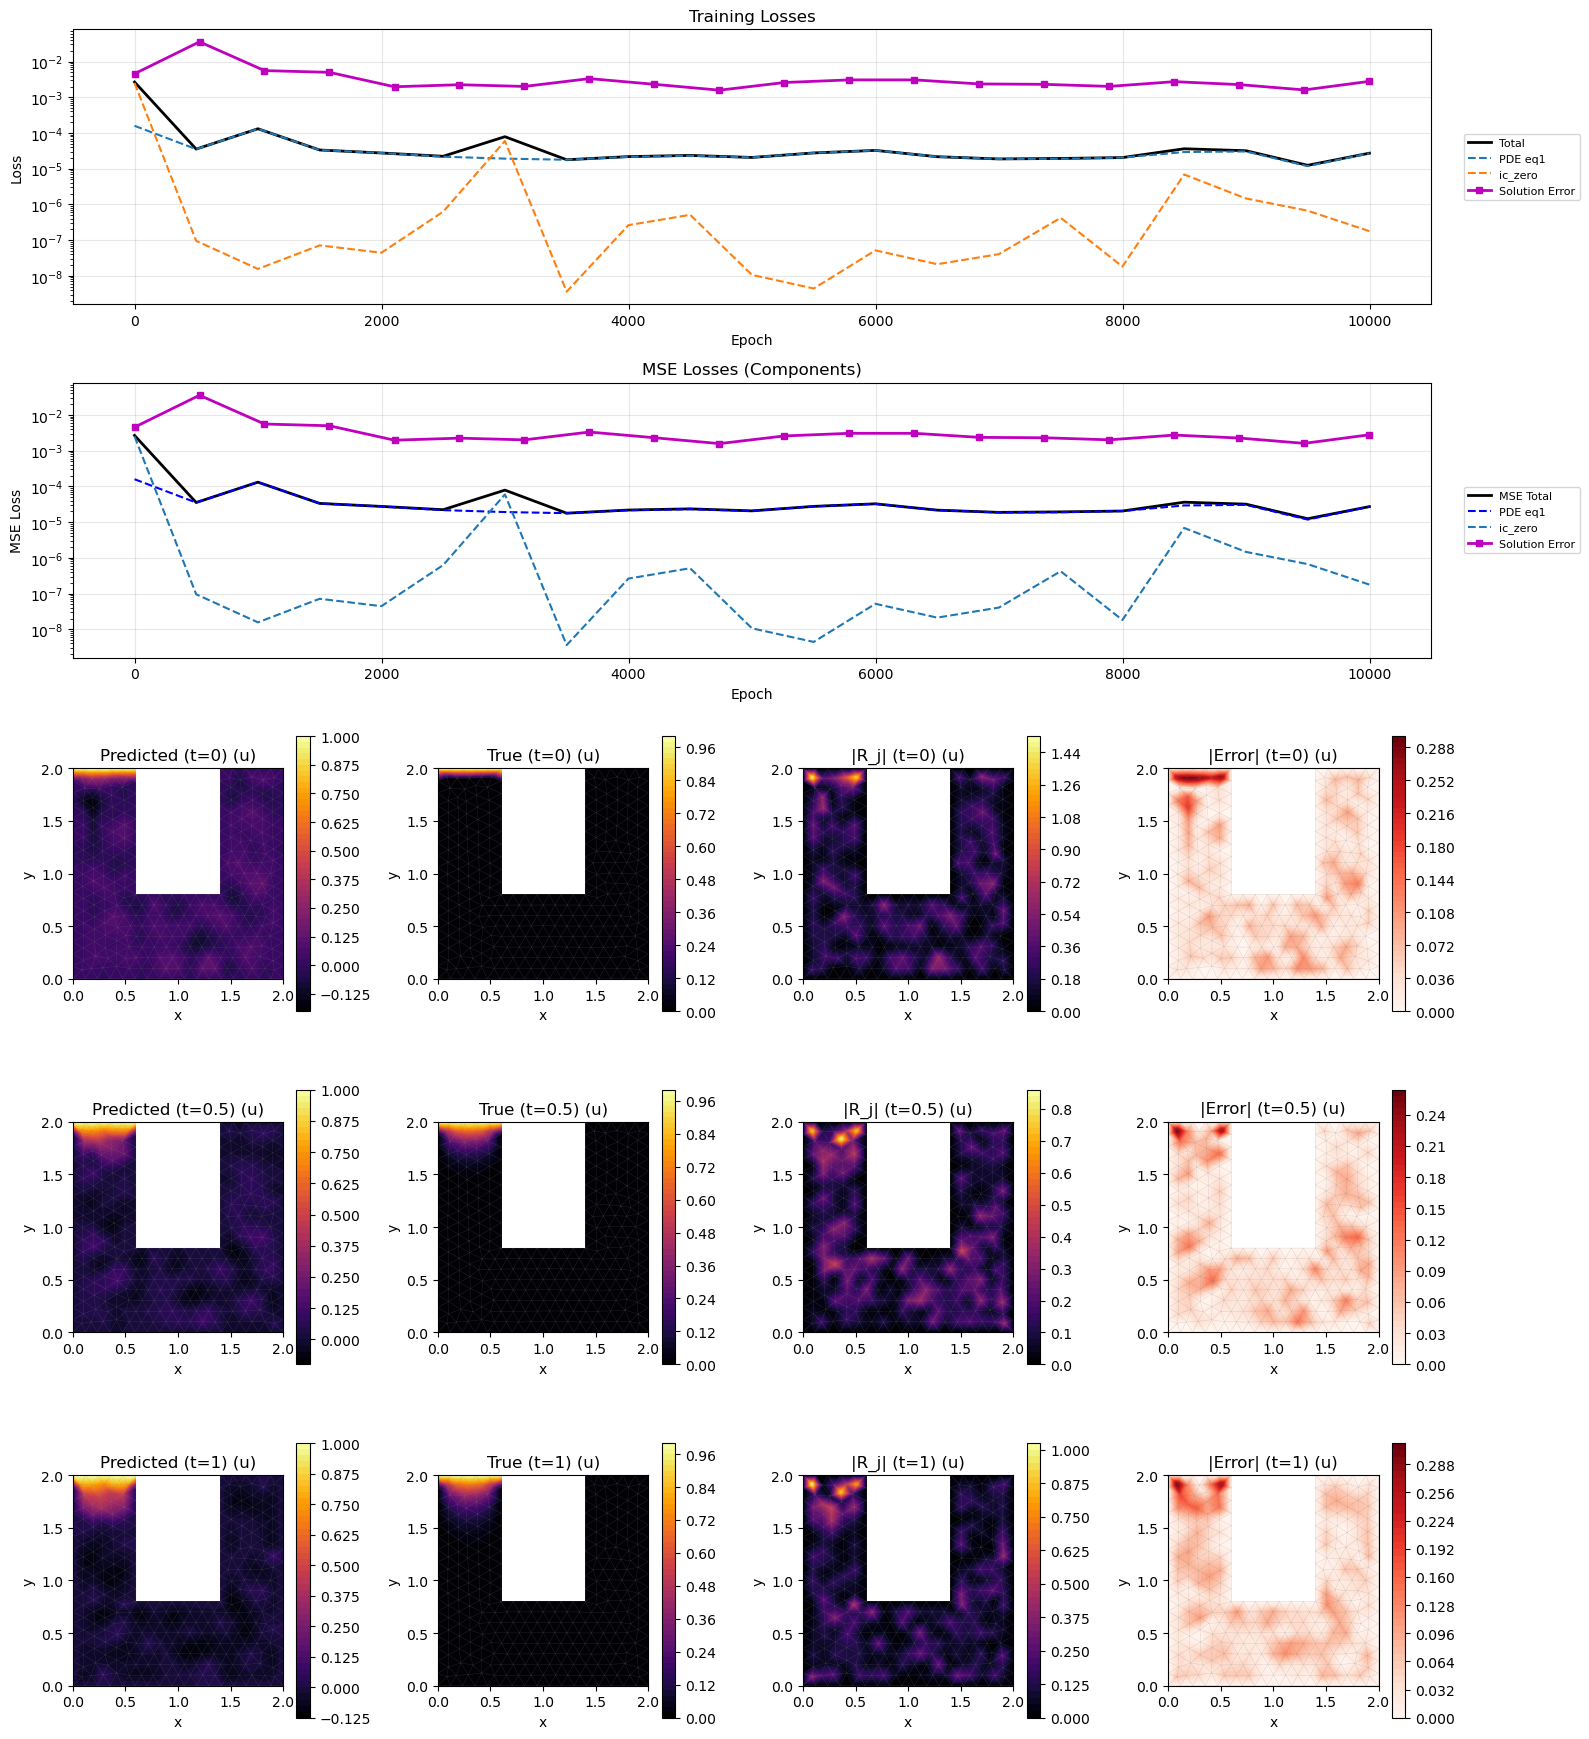

Starting Trainer (JAX, Lagrangian mode) for 10000 epochs...
Epoch 0/10000 | MSE Loss: 2.67e-03 | PDE: 1.59e-04 | BCs: [ic_zero: 2.52e-03]
Epoch 500/10000 | AL Loss: 2.78e-04 | MSE Loss: 3.54e-05 | PDE: 3.53e-05 | BCs: [ic_zero: 9.53e-08] | Time: 12.9s | Error: 4.55e-03
Epoch 1000/10000 | AL Loss: -4.66e-05 | MSE Loss: 1.31e-04 | PDE: 1.31e-04 | BCs: [ic_zero: 1.56e-08] | Time: 23.3s | Error: 3.56e-02
Epoch 1500/10000 | AL Loss: -4.23e-05 | MSE Loss: 3.34e-05 | PDE: 3.33e-05 | BCs: [ic_zero: 7.13e-08] | Time: 33.4s | Error: 5.58e-03
Epoch 2000/10000 | AL Loss: 3.43e-06 | MSE Loss: 2.75e-05 | PDE: 2.75e-05 | BCs: [ic_zero: 4.44e-08] | Time: 43.7s | Error: 4.98e-03
Epoch 2500/10000 | AL Loss: -5.66e-06 | MSE Loss: 2.23e-05 | PDE: 2.16e-05 | BCs: [ic_zero: 6.26e-07] | Time: 53.9s | Error: 1.97e-03
Epoch 3000/10000 | AL Loss: 6.30e-05 | MSE Loss: 7.87e-05 | PDE: 1.91e-05 | BCs: [ic_zero: 5.95e-05] | Time: 63.9s | Error: 2.24e-03
Epoch 3500/10000 | AL Loss: -1.67e-05 | MSE Loss: 1.78e-05 | P

In [16]:
trainer = Trainer(problem, net)
trainer.compile(
    learning_rate  = 1e-3,
    lagrange_lr    = 1e-3,
    epochs         = 10_000,
    print_each     = 500,
    show_plots     = True,
    plot_time_points = [0.0, 0.5, 1.0],
    # The IC (ic_zero) is a soft constraint competing against the PDE loss.
    # Without a large weight it gets overpowered and the network collapses
    # to the steady-state solution (satisfies PDE + BCs for all t trivially).
    weights = {
        "pde":        1.0,
        "hot_top":    1.0,   # hard-constrained, weight has no effect
        "cold_walls": 1.0,   # hard-constrained, weight has no effect
        "ic_zero":    1.0,   # boost IC to compete with PDE loss
    },
)
trainer.train()